# Day 2

Today, we will start using nf-core pipelines to find differentially abundant genes in our dataset. 
We are using data from the following paper: https://www.nature.com/articles/s41593-023-01350-3#Sec10

1. Please take some time to read through the paper and understand their approach, hypotheses and goals.

What was the objective of the study?

They wanted to understand how the body reacts when you have a oxicodon withdrawl and the difference it makes if at that point you are in cronic pain or not. To work against the cronic pain, they tested the HDAC inhibitors which are upstream regulators in oxy withdrawl and test the difference in reaction if that inhibitor is given or not. They tested different behavorial for the Mice and also did some RNA analysis on the brians.

What do the conditions mean?

oxy: Oxycodon, Treatment group


sal: Saline, Controll group

What do the genotypes mean?

SNI: spared nerve injury


Sham: controll group

Imagine you are the bioinformatician in the group who conducted this study. They hand you the raw files and ask you to analyze them.

What would you do?
Identify the features and get a generell overlook over the data before starting to compare the different groups with each other. Also talk with the group what they want to analyse and what they did to get to know the features. Normalise the data and look for bias.

Which groups would you compare to each other?
-We should have 4 groups: SNI-Sal, SNI-Oxy, Sham-Sal and Sham-Oxy
-We compare in between the SNI and Sham group and then also between the Sal and Oxy group.


Please also mention which outcome you would expect to see from each comparison.
-I would expect a big difference in behaviour and brain chemistry when comparing the Sal and Oxy groups but not that big of a differnce ehen comparing between the SNI and Sham groups.


Your group gave you a very suboptimal excel sheet (conditions_runs_oxy_project.xlsx) to get the information you need for each run they uploaded to the SRA.<br>
So, instead of directly diving into downloading the data and starting the analysis, you first need to sort the lazy table.<br>
Use Python and Pandas to get the table into a more sensible order.<br>
Then, perform some overview analysis and plot the results
1. How many samples do you have per condition?
2. How many samples do you have per genotype?
3. How often do you have each condition per genotype?

In [22]:
import pandas as pd

df = pd.read_excel("conditions_runs_oxy_project.xlsx")

#print(df.head(20))

#put conditions together
genotype_cols = ["Genotype: SNI", "Genotype: Sham"]
condition_cols = ["condition: Sal", "Condition: Oxy"]

#created sorted dataframe
df_sorted = pd.DataFrame(
    {
    "Patient": df["Patient"],
    "Run": df["Run"],
    "RNA-seq": df["RNA-seq"],
    # Oxy = 1, Sal = 0
    "Condition": df["Condition: Oxy"].eq("x").astype(int),
    # SNI = 1, Sham = 0
    "Genotype": df["Genotype: SNI"].eq("x").astype(int),
    }
)

df_sorted = df_sorted.sort_values(
    by=["Genotype", "Condition"]
).reset_index(drop=True)

print(df_sorted)

print("Number of samples per condition:")

df_sorted.value_counts("Condition")

   Patient          Run RNA-seq  Condition  Genotype
0        ?  SRR23195507       x          0         0
1        ?  SRR23195512       x          0         0
2        ?  SRR23195515       x          0         0
3        ?  SRR23195520       x          0         0
4        ?  SRR23195506       x          1         0
5        ?  SRR23195511       x          1         0
6        ?  SRR23195514       x          1         0
7        ?  SRR23195519       x          1         0
8        ?  SRR23195505       x          0         1
9        ?  SRR23195510       x          0         1
10       ?  SRR23195513       x          0         1
11       ?  SRR23195518       x          0         1
12       ?  SRR23195508       x          1         1
13       ?  SRR23195509       x          1         1
14       ?  SRR23195516       x          1         1
15       ?  SRR23195517       x          1         1
Number of samples per condition:


Condition
0    8
1    8
Name: count, dtype: int64

In [23]:
print("Number of samples per Genotype")

df_sorted.value_counts("Genotype")

Number of samples per Genotype


Genotype
0    8
1    8
Name: count, dtype: int64

Number of samples per condition in each genotype. 0 as controll and 1 as treatment group.


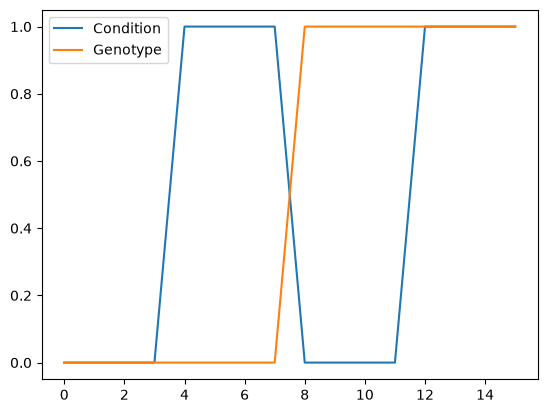

In [29]:
print("Number of samples per condition in each genotype. 0 as controll and 1 as treatment group.")
df_sorted.value_counts(["Genotype", "Condition"])

#Panda plots for the genotype and conditions
import matplotlib.pyplot as plt

df_sorted.plot()

plt.show()

They were so kind to also provide you with the information of the number of bases per run, so that you can know how much space the data will take on your Cluster.<br>
Add a new column to your fancy table with this information (base_counts.csv) and sort your dataframe according to this information and the condition.

Then select the 2 smallest runs from your dataset and download them from SRA (maybe an nf-core pipeline can help here?...)

In [30]:
bc = pd.read_csv("base_counts.csv")

#print(bc)

df_merged = pd.merge(df_sorted, bc, on="Run")
df_merged = df_merged.sort_values(["Bases", "Condition"])

In [31]:
print(df_merged.head(2))

   Patient          Run RNA-seq  Condition  Genotype       Bases
14       ?  SRR23195516       x          1         1  6203117700
5        ?  SRR23195511       x          1         0  6456390900


In [ ]:
#Data here available  GSE223541
#using the fetchngs nf-core pipeline
#only downloading the 2 smallest Runs (SRR23195516, SRR23195511)

!echo -e "id\nSRR23195516\nSRR23195511" > ids.csv

!nextflow run nf-core/fetchngs --input ./ids.csv --outdir ./results -profile docker

While your files are downloading, get back to the paper and explain how you would try to reproduce the analysis.<br>
When you are done with this shout, so we can discuss the different ideas.

For the reproduce we could be using the rnaseq piepline for the Alignment and REad counting and for the DE2-Seq design and the heatmaps we can use the differentialabundance pipeline from yesterday.